# Vapor-Eyes 01 — Wide-area screening: Sentinel-5P → methane hotspots

**Methane super-emitter hunt, step 1: cast the wide net.** Before we can pinpoint a leak we need to know *where to look*. This notebook screens the Permian/Delaware-Basin AOI with daily **Sentinel-5P TROPOMI** methane and surfaces candidate super-emitter cells:

- **Stage** the S5P CH4 granule(s) for the AOI with `TropomiDownloader` (Planetary Computer).
- **Read** the netCDF-4 **swath** as per-pixel points via the lightweight **`netcdf_gbx` vector** reader — no regridding.
- **Quality-filter** on the S5P `qa_value` (Databricks does no filtering for us).
- **Bin** the column enhancements into **H3 cells** with native `h3_longlatash3` and aggregate per cell.

**Result:** a regional methane hotspot map — the candidate cells notebooks 02–03 zoom into at 20 m and 60 m.

---
_Last Modified:_ July 11, 2026

![Sentinel-5P swath → netcdf_gbx vector points → H3 hotspot cells → regional map](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/vapor-eyes/vapor-eyes-01.png)

In [0]:
%run ./config_nb

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... EARTHDATA_TOKEN loaded from geospatial_docs.vapor_eyes.earthdata_token


... skipping spark.conf.set(spark.sql.adaptive.coalescePartitions.enabled) [Serverless?]: AnalysisException


True

... catalog: 'geospatial_docs' (USE)
... schema:  'vapor_eyes' (CREATE / USE)


... VAPOR_EYES_DIR: '/Volumes/geospatial_docs/vapor_eyes/data/vapor-eyes' (MKDIRS s5p/ sentinel2/ emit/ wells/ tiles/)
... AOI (SMALL): (-103.25, 31.3, -102.85, 31.62)  (via get_aoi_bbox(); re-reads FULL_AOI each call)
... DATE_WINDOW: 2023-07-15/2023-08-20
... toggles: FULL_AOI=False  FORCE_REBUILD=False  INTERACTIVE_PLOTS=False


... downloaders: tropomi, emit, wells | stac_client | vizx: plot_raster, plot_tile, cells_as_gdf, plot_pmtiles


... view helpers: show_cells, show_tile, show_pmtiles (gated by INTERACTIVE_PLOTS)


In [0]:
FORCE_REBUILD = False
INTERACTIVE_PLOTS = False

# Scope S5P to a single daily overpass (near an EMIT overpass over the cluster) so
# the pull is one granule, not the season. H3 res-6 (~3 km edge) suits the 7 km S5P
# pixel; qa_value >= 0.5 is the S5P-recommended CH4 quality cut. Override per run.
S5P_TEMPORAL = "2024-08-23/2024-08-24"
H3_RES = 6
QA_MIN = 0.5

## 1. Stage the S5P CH4 granule(s) + catalog them

`TropomiDownloader` (a `gbx.sample` client, like `NaipDownloader`/`DemDownloader`)
searches Planetary Computer's `sentinel-5p-l2-netcdf` collection for the AOI +
window, fans the granule fetch out across the cluster, validates each `.nc`, and
returns the shared download contract. We persist a **`s5p_granules`** catalog —
one row per granule with its Volume `ch4_path`. This hits the network, so it is
**skipped on re-runs** once the table exists (staged `.nc` files persist);
`FORCE_REBUILD = True` forces a re-pull.

In [0]:
if FORCE_REBUILD or not spark.catalog.tableExists("s5p_granules"):
    s5p_dl = tropomi.download(get_aoi_bbox(), S5P_DIR, temporal=S5P_TEMPORAL, spark=spark)
    granules = s5p_dl.withColumnRenamed("out_file_path", "ch4_path").select(
        "item_id", "asset_name", "ch4_path", "out_file_sz", "is_out_file_valid", "last_update"
    )
    finalize_delta(granules, "s5p_granules")
else:
    print("... s5p_granules exists; skipping S5P search/download (FORCE_REBUILD=False)")
    spark.table("s5p_granules").printSchema()

... s5p_granules exists; skipping S5P search/download (FORCE_REBUILD=False)
root
 |-- item_id: string (nullable = true)
 |-- asset_name: string (nullable = true)
 |-- ch4_path: string (nullable = true)
 |-- out_file_sz: long (nullable = true)
 |-- is_out_file_valid: boolean (nullable = true)
 |-- last_update: timestamp (nullable = true)



## 2. Read the swath as per-pixel CH4 points (`netcdf_gbx` vector)

S5P L2 is netCDF-4 **swath** data — 2-D `latitude`/`longitude` per ground pixel,
not a regular grid. The lightweight **`netcdf_gbx` reader in `vector` mode** emits
**one point per ground pixel** (cell-centre lon/lat as WKB + the requested
variables as columns) — lossless, no regridding or resampling. `TropomiDownloader.read`
wires it up over the `/PRODUCT` group for `methane_mixing_ratio_bias_corrected` and
`qa_value`. Because the reader passes `qa_value` straight through, **we** apply the
quality cut (nothing is filtered for us).

In [0]:
pts = tropomi.read(S5P_DIR)  # cols: methane_mixing_ratio_bias_corrected, qa_value, geom_0(+srid)
pts = pts.filter(
    (F.col("qa_value") >= QA_MIN)
    & F.col("methane_mixing_ratio_bias_corrected").isNotNull()
)
print(f"... quality-filtered S5P points: {pts.count():,}")

... quality-filtered S5P points: 36,134


## 3. Clip to the AOI, bin to H3, aggregate → hotspots

The swath spans far more than our AOI, so we compose the points with
**Databricks built-in spatial + H3** functions: `st_geomfromwkb` rebuilds the
point geometry from the reader's WKB, `st_x`/`st_y` recover lon/lat to clip to the
AOI bbox, and `h3_longlatash3` bins each surviving point into an H3 res-6 cell. We
aggregate mean/max CH4 per cell, and `h3_centeraswkb` reconstructs a cell-centre
geometry — landing a **`s5p_hotspots`** table.

In [0]:
minx, miny, maxx, maxy = get_aoi_bbox()
pts = (
    pts.withColumn("_g", DBF.st_geomfromwkb(F.col("geom_0")))
    .withColumn("lon", DBF.st_x("_g"))
    .withColumn("lat", DBF.st_y("_g"))
    .filter((F.col("lon") >= minx) & (F.col("lon") <= maxx))
    .filter((F.col("lat") >= miny) & (F.col("lat") <= maxy))
    .withColumn("h3_cellid", DBF.h3_longlatash3("lon", "lat", F.lit(H3_RES)))
)
hotspots = (
    pts.groupBy("h3_cellid")
    .agg(
        F.mean("methane_mixing_ratio_bias_corrected").alias("ch4_mean"),
        F.max("methane_mixing_ratio_bias_corrected").alias("ch4_max"),
        F.count("*").alias("n_obs"),
    )
    .withColumn("geom_wkb", DBF.h3_centeraswkb("h3_cellid"))
)
finalize_delta(hotspots, "s5p_hotspots")

... table s5p_hotspots exists (skip; FORCE_REBUILD=False)
root
 |-- h3_cellid: long (nullable = true)
 |-- ch4_mean: double (nullable = true)
 |-- ch4_max: float (nullable = true)
 |-- n_obs: long (nullable = true)
 |-- geom_wkb: binary (nullable = true)



DataFrame[h3_cellid: bigint, ch4_mean: double, ch4_max: float, n_obs: bigint, geom_wkb: binary]

## 4. Regional methane hotspot map

The top cells by peak CH4 are the candidate super-emitter locations. (Preview uses
`show(vertical=True)` rather than `display()` — the `geom_wkb` column renders as an
ugly blob in a committed notebook.)

In [0]:
top = spark.table("s5p_hotspots").orderBy(F.desc("ch4_max")).limit(20)
print(f"... s5p_hotspots: {spark.table('s5p_hotspots').count():,} cells (showing top by peak CH4)")
# display(top)
top.limit(1).show(vertical=True)  # <- for ipynb in GitHub (geom_wkb column)

... s5p_hotspots: 12 cells (showing top by peak CH4)
-RECORD 0-------------------------
 h3_cellid | 604758428606267391   
 ch4_mean  | 1905.52490234375     
 ch4_max   | 1905.5249            
 n_obs     | 1                    
 geom_wkb  | [01 01 00 00 00 B... 



A CH4 choropleth of the H3 cells for regional context, rendered through the series'
`show_cells` helper (from `config_nb`): the default draws `cells_as_gdf` hexagons over
a CartoDB basemap, zoomed out for context; set `INTERACTIVE_PLOTS = True` in
`config_nb` for a MapLibre map (`grid_layer`) instead.

<Axes: title={'center': 'S5P CH4 hotspots over the Delaware Basin AOI (H3 res 6, mean column)'}>

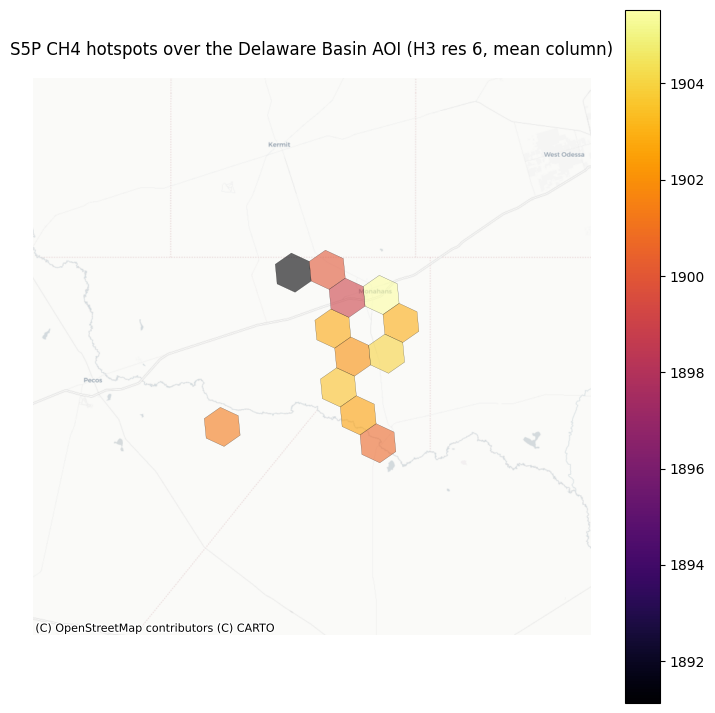

In [0]:
_b = get_aoi_bbox()
_center = [(_b[0] + _b[2]) / 2, (_b[1] + _b[3]) / 2]
show_cells(
    spark.table("s5p_hotspots"),
    cellid_col="h3_cellid",
    column="ch4_mean",
    label="CH4 mean (mol/m²)",
    title="S5P CH4 hotspots over the Delaware Basin AOI (H3 res 6, mean column)",
    center=_center,
    zoom=9,
)

## What we built

- **`s5p_granules`** (Delta) — the staged-granule catalog (Volume `ch4_path` per `.nc`).
- **`s5p_hotspots`** (Delta) — per-H3-cell CH4 mean/max/obs-count + cell geometry.
- A **regional hotspot map** — the candidate super-emitter cells.

GeoBrix: `TropomiDownloader`, the **`netcdf_gbx` vector reader**, `gbx.vizx.cells_as_gdf`.
Databricks-native: `st_geomfromwkb`, `st_x`/`st_y`, `h3_longlatash3`, `h3_centeraswkb`.

Next: **notebook 02** zooms a hotspot to 20 m with Sentinel-2 SWIR (MBMP) to detect the plume.